# Global Data Center Resource Consumption Analysis

## Objective

- The objective of this project is to analyze resource consumption,operational efficiency, and sustainability metrics across global data centers.

## The analysis focuses on:

- Electricity consumption
- Water consumption
- Power Usage Effectiveness (PUE)
- Cooling system efficiency
- Facility type comparisons
- Data quality assessment

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("data_center_hybrid.csv")
df.head(5)

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


In [102]:
print(df.shape)

(126770, 15)


 Dataset contains approximately 126,000 records and 14 variables covering data center operations across multiple countries and facility types.

## Knowing about Data (Info, Description, NullValues, Duplicate Values)

In [16]:
# null values in the data.
df.isnull().sum()

Year                             0
Facility_ID                      0
Facility_Name                    0
Owner_Company                    0
City                             0
Country                          0
Facility_Type                    0
Estimated_Capacity_MW            0
PUE                              0
Cooling_System_Type              0
WUE_L_per_kWh                    0
Daily_Electricity_Usage_MWh      0
Daily_Water_Usage_Gallons        0
Surrounding_Water_Stress_Tier    0
dtype: int64

In [18]:
# Dupilcated values in data.
df.duplicated().sum()

0

In [20]:
df.drop_duplicates(inplace=True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126770 entries, 0 to 126769
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Year                           126770 non-null  int64  
 1   Facility_ID                    126770 non-null  object 
 2   Facility_Name                  126770 non-null  object 
 3   Owner_Company                  126770 non-null  object 
 4   City                           126770 non-null  object 
 5   Country                        126770 non-null  object 
 6   Facility_Type                  126770 non-null  object 
 7   Estimated_Capacity_MW          126770 non-null  float64
 8   PUE                            126770 non-null  float64
 9   Cooling_System_Type            126770 non-null  object 
 10  WUE_L_per_kWh                  126770 non-null  float64
 11  Daily_Electricity_Usage_MWh    126770 non-null  float64
 12  Daily_Water_Usage_Gallons     

In [26]:
df.describe()

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000,1.267700e+05
mean,2022.000000,23.075117,1.637746,0.820596,605.222368,1.312182e+05
std,2.000008,45.847195,0.190833,0.925481,1040.061940,3.979629e+05
min,2019.000000,1.000000,1.057000,0.001000,22.190000,2.240100e+02
25%,2020.000000,5.450000,1.518000,0.139000,167.432500,4.840538e+03
50%,2022.000000,9.870000,1.643000,0.232000,302.750000,1.218130e+04
75%,2024.000000,14.180000,1.787000,1.654000,451.370000,7.573068e+04
max,2025.000000,562.890000,2.000000,3.000000,14812.660000,7.585092e+06


## Outlier Analysis

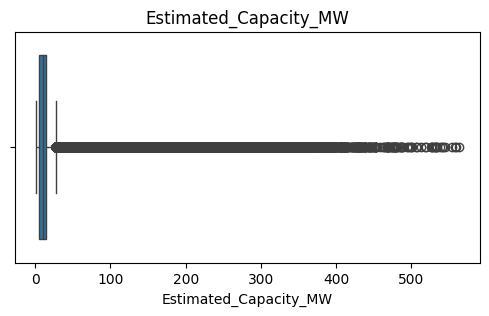

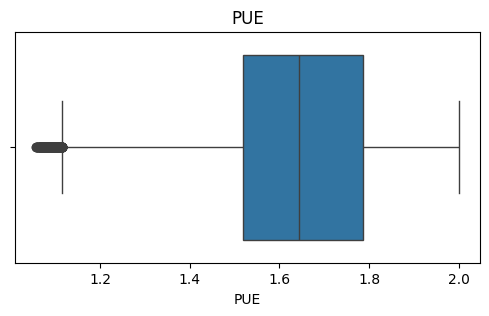

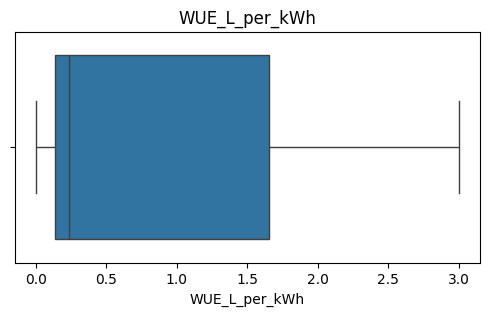

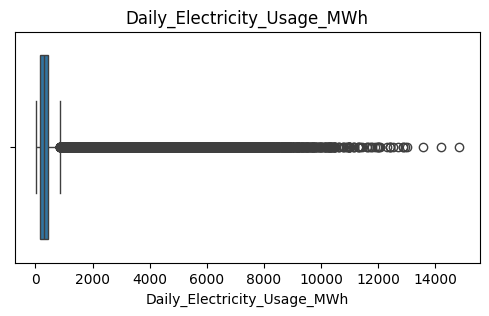

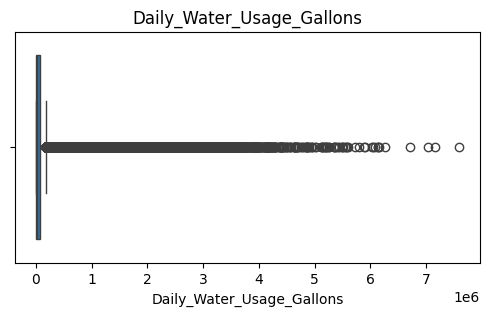

In [31]:
num_cols = [
    'Estimated_Capacity_MW',
    'PUE',
    'WUE_L_per_kWh',
    'Daily_Electricity_Usage_MWh',
    'Daily_Water_Usage_Gallons'
]

for col in num_cols:
    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)
    plt.show()

## Data Visualisations

<Axes: xlabel='Year', ylabel='Daily_Electricity_Usage_MWh'>

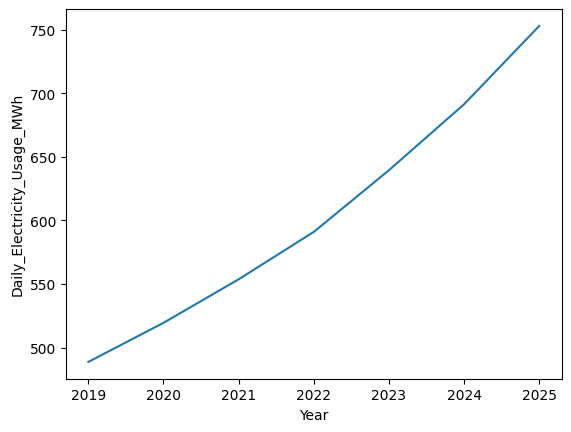

In [33]:
yearly = (
    df.groupby('Year')
      ['Daily_Electricity_Usage_MWh']
      .mean()
      .reset_index()
)

sns.lineplot(
    data=yearly,
    x='Year',
    y='Daily_Electricity_Usage_MWh'
)

In [111]:
water_yearly = (
    df.groupby('Year')
      ['Daily_Water_Usage_Gallons']
      .mean()
      .reset_index()
)
water_yearly.head(5)

,Year,Daily_Water_Usage_Gallons
0,2019,99199.807287
1,2020,107425.285302
2,2021,117198.163073
3,2022,127417.169295
4,2023,140398.471702


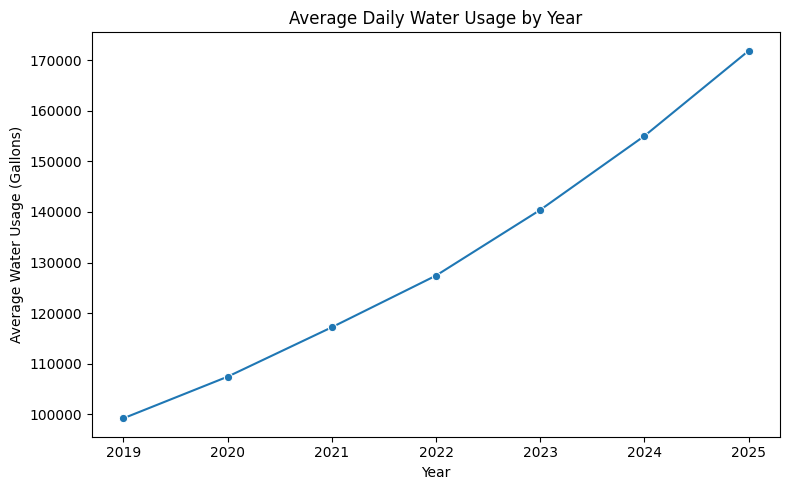

In [113]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=water_yearly,
    x='Year',
    y='Daily_Water_Usage_Gallons',
    marker='o'
)

plt.title('Average Daily Water Usage by Year')
plt.xlabel('Year')
plt.ylabel('Average Water Usage (Gallons)')
plt.tight_layout()

plt.show()

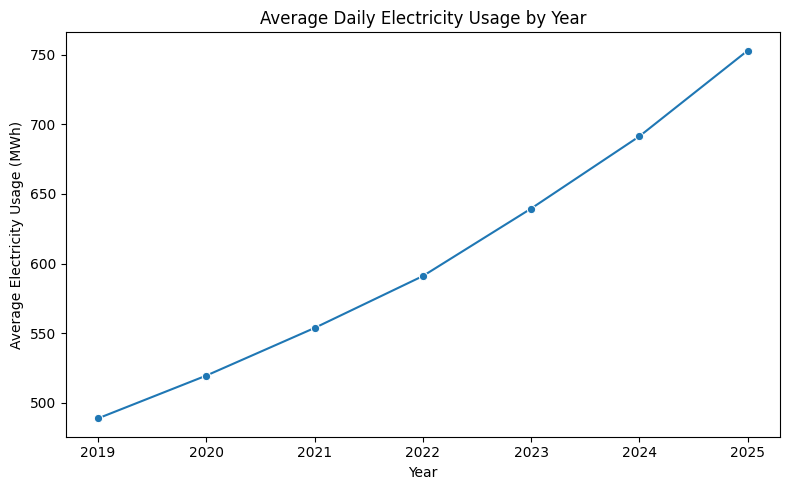

In [117]:
electricity_yearly = (
    df.groupby('Year')
      ['Daily_Electricity_Usage_MWh']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=electricity_yearly,
    x='Year',
    y='Daily_Electricity_Usage_MWh',
    marker='o'
)

plt.title('Average Daily Electricity Usage by Year')
plt.xlabel('Year')
plt.ylabel('Average Electricity Usage (MWh)')
plt.tight_layout()

plt.show()

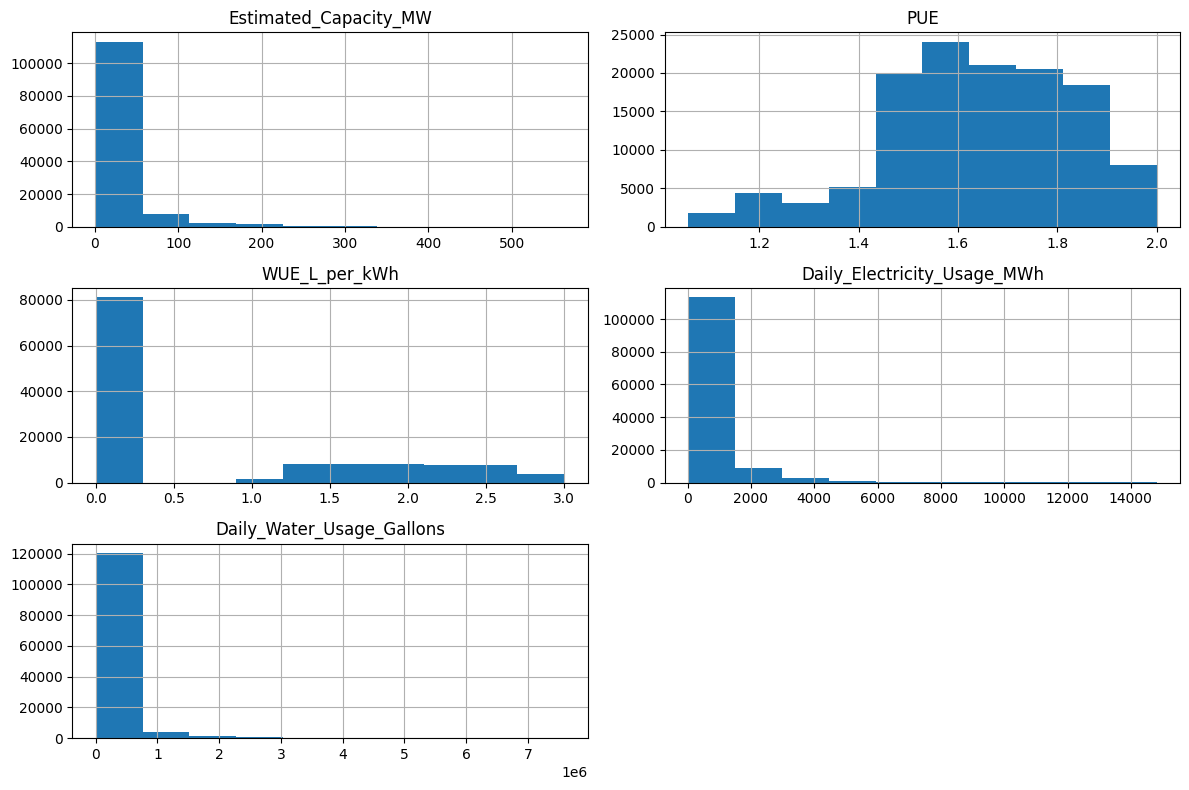

In [41]:
num_cols = [
    'Estimated_Capacity_MW',
    'PUE',
    'WUE_L_per_kWh',
    'Daily_Electricity_Usage_MWh',
    'Daily_Water_Usage_Gallons'
]

df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

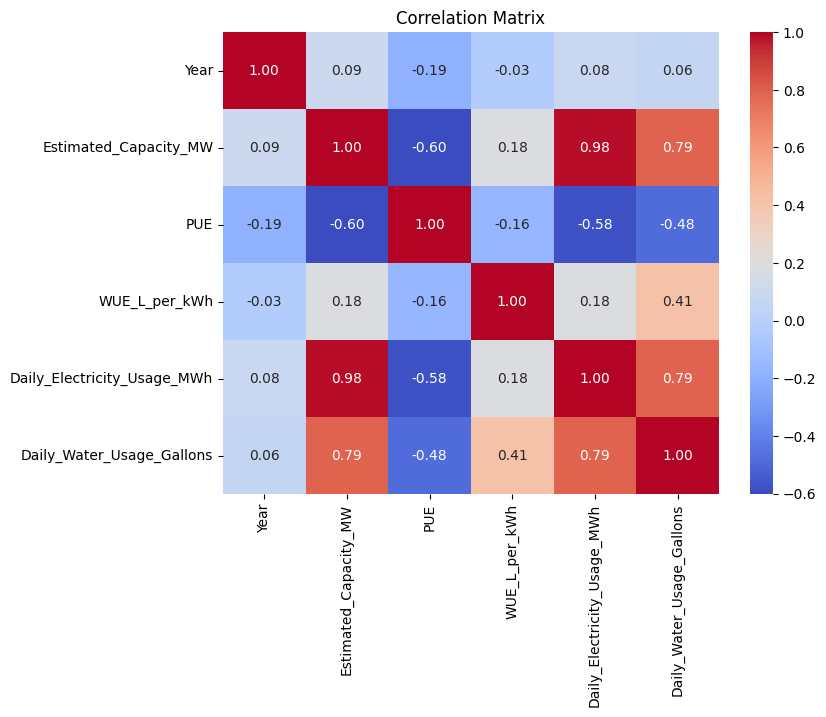

In [43]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

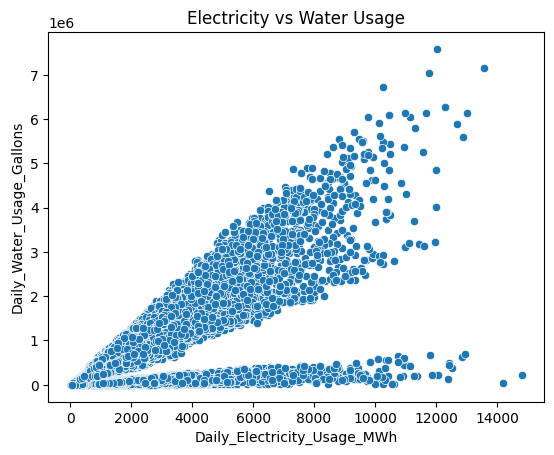

In [45]:
sns.scatterplot(
    data=df,
    x='Daily_Electricity_Usage_MWh',
    y='Daily_Water_Usage_Gallons'
)

plt.title('Electricity vs Water Usage')
plt.show()

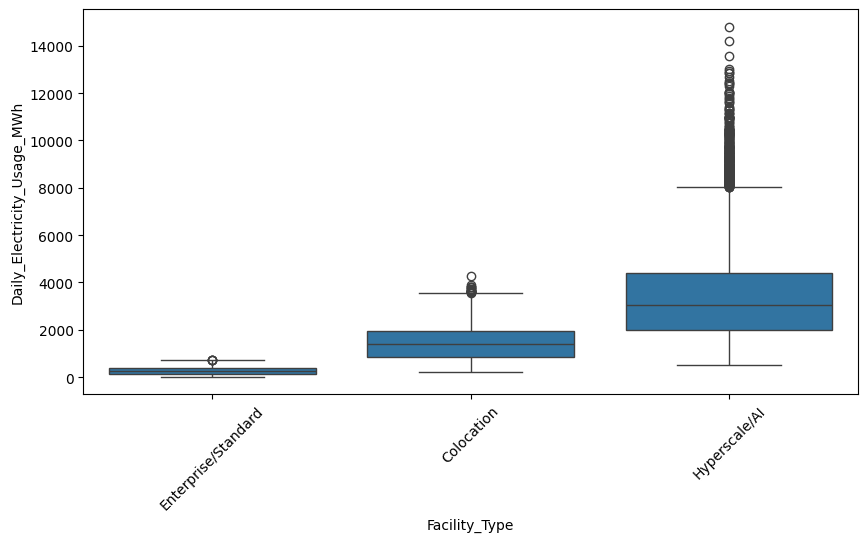

In [47]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x='Facility_Type',
    y='Daily_Electricity_Usage_MWh'
)

plt.xticks(rotation=45)
plt.show()

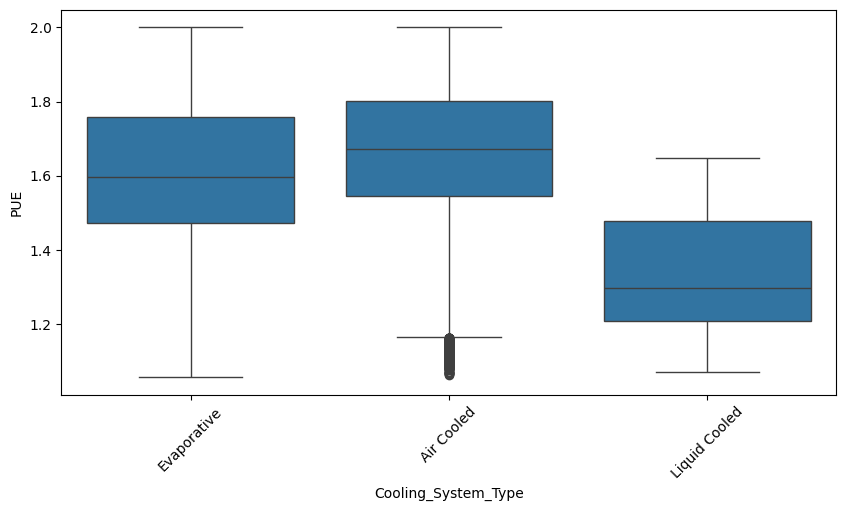

In [49]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Cooling_System_Type',
    y='PUE'
)

plt.xticks(rotation=45)
plt.show()

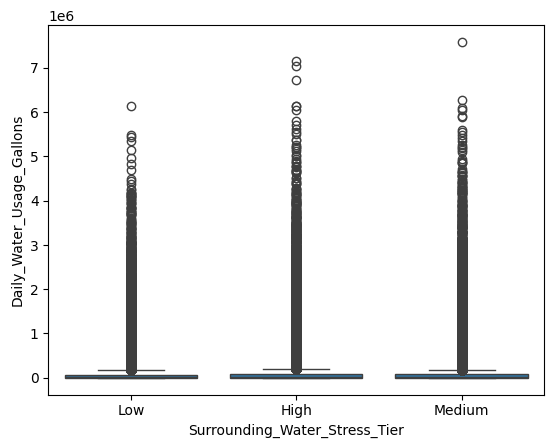

In [51]:
sns.boxplot(
    data=df,
    x='Surrounding_Water_Stress_Tier',
    y='Daily_Water_Usage_Gallons'
)

plt.show()

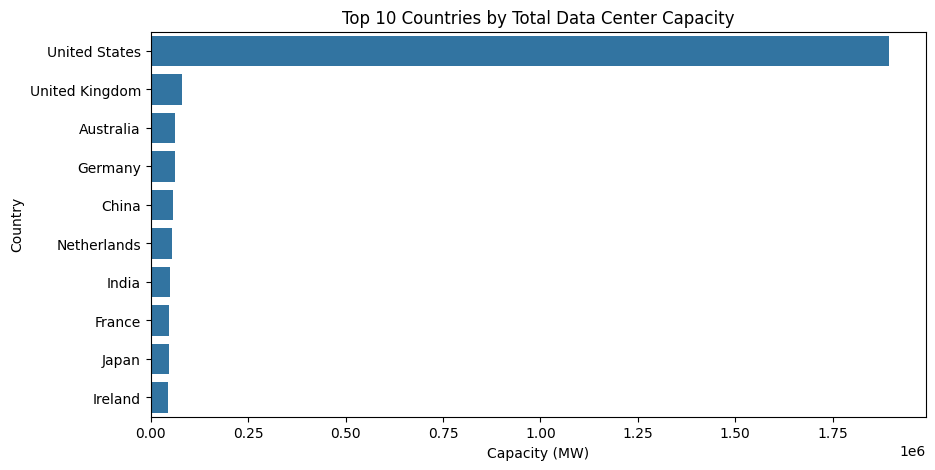

In [68]:
country_cap = (
    df.groupby('Country')
      ['Estimated_Capacity_MW']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=country_cap.values,
    y=country_cap.index
)

plt.title('Top 10 Countries by Total Data Center Capacity')
plt.xlabel('Capacity (MW)')
plt.ylabel('Country')

plt.show()

In [93]:
df.groupby('Facility_Type')[
    ['Daily_Water_Usage_Gallons',
     'Daily_Electricity_Usage_MWh',
     'PUE']
].mean()

,Daily_Water_Usage_Gallons,Daily_Electricity_Usage_MWh,PUE
Facility_Type,,,
Colocation,2.983745e+05,1425.906661,1.479179
Enterprise/Standard,3.003673e+04,262.811031,1.693435
Hyperscale/AI,1.074522e+06,3445.401239,1.210476


### Facility Type Analysis

#### Hyperscale/AI data centers exhibit the highest average electricity consumption (3,445 MWh/day) and water consumption (1.07 million gallons/day), reflecting the substantial resource requirements of large-scale AI and cloud computing operations. Despite this high resource demand, Hyperscale/AI facilities achieve the lowest average PUE (1.21), making them the most energy-efficient facility type in the dataset.

#### In contrast, Enterprise/Standard facilities consume significantly fewer resources but record the highest average PUE (1.69), indicating lower operational efficiency. This suggests that larger-scale facilities may benefit from advanced cooling technologies and infrastructure optimization that improve energy efficiency.

In [95]:
df['Water_per_MWh'] = (
    df['Daily_Water_Usage_Gallons'] /
    df['Daily_Electricity_Usage_MWh']
)

df.groupby('Facility_Type')[
    'Water_per_MWh'
].mean()

Facility_Type
Colocation             207.797280
Enterprise/Standard    114.203299
Hyperscale/AI          314.773236
Name: Water_per_MWh, dtype: float64

### Resource Efficiency Trade-off

#### While Hyperscale/AI facilities achieved the best energy efficiency with an average PUE of 1.21, they also exhibited the highest water intensity, consuming approximately 315 gallons of water per MWh of electricity. In contrast, Enterprise/Standard facilities had the poorest energy efficiency (PUE = 1.69) but required only 114 gallons of water per MWh. This suggests a trade-off between energy optimization and water consumption, highlighting the importance of evaluating data center sustainability across multiple resource dimensions rather than relying solely on PUE.

## Business Questions

## Which cooling system is most efficient?

In [57]:
df.groupby(
    'Cooling_System_Type'
)['PUE'].mean().sort_values()

Cooling_System_Type
Liquid Cooled    1.337023
Evaporative      1.591939
Air Cooled       1.670127
Name: PUE, dtype: float64

#### Conclusion
#### Liquid-cooled facilities are the most energy-efficient in the dataset, with the lowest average PUE of 1.337
#### Air-cooled facilities are the least efficient, with an average PUE of 1.670.

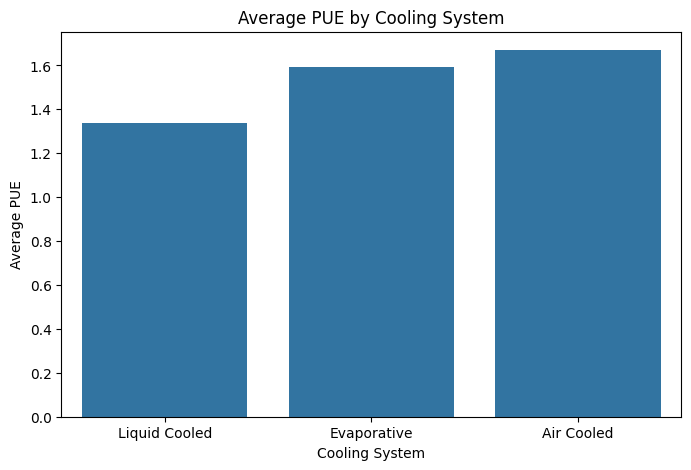

In [70]:
cooling_pue = (
    df.groupby('Cooling_System_Type')['PUE']
      .mean()
      .sort_values()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=cooling_pue,
    x='Cooling_System_Type',
    y='PUE'
)

plt.title('Average PUE by Cooling System')
plt.xlabel('Cooling System')
plt.ylabel('Average PUE')

plt.show()

## Which countries have best efficiency?

In [62]:
df.groupby(
    'Country'
)['PUE'].mean().sort_values()

Country
maruo osaka ビルディング                        1.123714
2 Chome−６−1                               1.186714
チバケンドウ4ゴウ                                 1.222000
Higashi-Shinagawa3 Chome−8−21 信州名鉄品川ビル    1.225429
Taiwan 507                                1.229286
                                            ...   
610011                                    1.905714
Singapore 409057                          1.910857
518107                                    1.913143
100102                                    1.914857
Noorwegen                                 1.933000
Name: PUE, Length: 344, dtype: float64

In [85]:
df['Country'].unique() 
# Data quality assessment revealed significant inconsistencies in the Country field. 
# The column contained country names, postal codes, addresses, facility names, 
# and multilingual representations of the same country. 
# Therefore, country-level efficiency analysis requires data cleaning before reliable conclusions can be drawn.

array(['Spain', 'Singapore', 'Romania', 'Ghana', 'Germany', 'Kuwait',
       'Qatar', 'United States', 'United Kingdom', 'Canada', 'Australia',
       'France', 'Nigeria', 'Netherlands', 'Unknown', 'Hong Kong',
       'Israel', 'Egypt', 'Japan', 'Mexico', 'Belgium', "Côte d'Ivoire",
       'United Arab Emirates', 'Taiwan', 'Malaysia', 'Afghanistan',
       'China', 'Ukraine', 'India', 'Armenia', 'Denmark', 'Iran',
       'New Zealand', 'Ireland', 'Malta', 'Italy', 'Estonia', 'Pakistan',
       'Kazakhstan', 'Thailand', 'Switzerland', 'Turkey', 'Brazil',
       'Austria', 'Angola', 'Jordan', 'Greece', 'Latvia', 'Argentina',
       'Sweden', 'Azerbaijan', 'Indonesia', 'Lithuania', 'Hungary',
       'Portugal', 'Poland', 'Lebanon', 'Tunisia', 'Serbia',
       'South Africa', 'Belarus', 'Montenegro', 'Luxembourg', 'Russia',
       'Colombia', 'Philippines', 'Slovakia', 'Czech Republic', 'Congo',
       'Bulgaria', 'Saudi Arabia', 'South Korea', 'Mauritius',
       'Venezuela', 'Algeria', '

## Which facility type consumes most water?

In [65]:
df.groupby(
    'Facility_Type'
)['Daily_Water_Usage_Gallons'].mean()

Facility_Type
Colocation             2.983745e+05
Enterprise/Standard    3.003673e+04
Hyperscale/AI          1.074522e+06
Name: Daily_Water_Usage_Gallons, dtype: float64

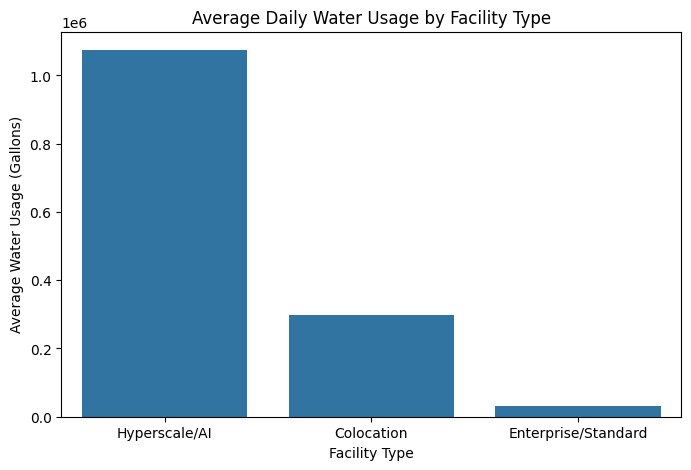

In [91]:
water_usage = (
    df.groupby('Facility_Type')
      ['Daily_Water_Usage_Gallons']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=water_usage,
    x='Facility_Type',
    y='Daily_Water_Usage_Gallons'
)

plt.title('Average Daily Water Usage by Facility Type')
plt.xlabel('Facility Type')
plt.ylabel('Average Water Usage (Gallons)')

plt.show()

#### Hyperscale/AI data centers exhibit the highest average daily water consumption at approximately 1.07 million gallons per day. This is more than three times the consumption of Colocation facilities and nearly thirty-six times that of Enterprise/Standard facilities. The result suggests that large-scale AI and cloud infrastructure places significantly greater demands on water resources, likely due to higher cooling requirements.

### Key Findings

1. Electricity usage strongly increases with facility capacity.
2. Water consumption differs substantially by water-stress region.
3. Certain cooling systems demonstrate lower PUE.
4. Capacity is positively correlated with electricity demand.
5. Country-level infrastructure differences affect efficiency.